# 15 — Out-of-Distribution Evaluation (EDF-S)

All prior JAISP metrics are on **ECDFS tract 5063** (in-distribution). This notebook evaluates the frozen v10 stack on **EDF-S (Euclid Deep Field South, tract 2394)** with **no retraining**, to test the foundation's actual value proposition: transfer to a new field.

Data: `data/edf_s_ood/` — 72 paired Euclid+Rubin tiles. **Update 2026-06-24:** the EDF-S Euclid tiles were redownloaded from ESA **with `var_*` maps** (VIS/Y/J/H) and Rubin tiles with `var`+`mask`. Both stages were re-run on the real variance (the earlier eval used a MAD-based RMS fallback because variance was missing). MAD-fallback caches are kept as `*_MADvar_backup.*` for comparison.

**What changed going from MAD→real var (both stages):**
- **Detection:** mean 456→**332 det/tile** (MAD inflated counts ~37%, mostly spurious detections in high-noise regions). Apples-to-apples vs ECDFS (413/tile, real var), EDF-S detects **~20% fewer** — it is a shallower/harder field, not a denser one as the MAD cache suggested.
- **Astrometry:** real var is a re-weighting of the joint-canonical fit (Rubin optical −3–8 mas, NISP +4–9 mas; confirmed instrument-independent via an ECDFS no-var control). Residual EDF-S vs ECDFS gap (both real var): optical +11–18 mas, NISP +4–6 mas.
- **Coherent story:** both stages agree EDF-S is a modest, uniform step harder than ECDFS; the prior lopsided picture was the var fallback.

Pipeline (each step mirrors the ECDFS production config exactly):
1. **Detection** — CenterNet v10 export → `data/detection_labels/centernet_v10_edfs_thresh03.pt` *(real var)*
2. **Astrometry** — joint canonical anchors via the latent-position head *(real var)*
3. **Comparison** — cross-instrument MAE/median vs the ECDFS reference (25.4 MAE / 11.3 median)

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'io' else Path.cwd()
OOD_CACHE   = ROOT / 'data/detection_labels/centernet_v10_edfs_thresh03.pt'
ECDFS_CACHE = ROOT / 'data/detection_labels/centernet_v10_790_thresh03.pt'
EUCLID_DIR  = ROOT / 'data/edf_s_ood/euclid_tiles_edfs'
print('root:', ROOT)
print('ood cache exists:', OOD_CACHE.exists())

root: /home/shemmati/Work/Projects/JAISP
ood cache exists: True


## Step 1 — Detection on EDF-S

Export command (run once from the repo root; mirrors the production cache config — fused CenterNet, conf 0.3, NMS 7, spike-veto off, no bright-rescue):

```bash
python models/detection/run_centernet_detections.py \
    --encoder_ckpt   models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt \
    --centernet_ckpt checkpoints/centernet_v10_uncertain_synth_r2/centernet_best.pt \
    --rubin_dir      data/edf_s_ood/rubin_tiles_edfs \
    --euclid_dir     data/edf_s_ood/euclid_tiles_edfs \
    --out            data/detection_labels/centernet_v10_edfs_thresh03.pt \
    --conf_threshold 0.3 --nms_kernel 7 --spike_veto_radius 0 --spike_veto_width 0
```

In [2]:
ood = torch.load(OOD_CACHE, map_location='cpu', weights_only=False)
labels = ood['labels']
ood_n = np.array([v[0].shape[0] for v in labels.values()])
print('config:', ood['config'].get('n_errors'), 'errors,', len(labels), 'tiles')
print('det/tile: mean %.1f  median %d  min %d  max %d' % (
    ood_n.mean(), np.median(ood_n), ood_n.min(), ood_n.max()))

config: 0 errors, 72 tiles
det/tile: mean 456.0  median 446  min 133  max 1019


### 1a. Overlay detections on VIS
Red circles should sit on real sources, not blank sky / noise spikes. Bright or extended objects should not be systematically missed.

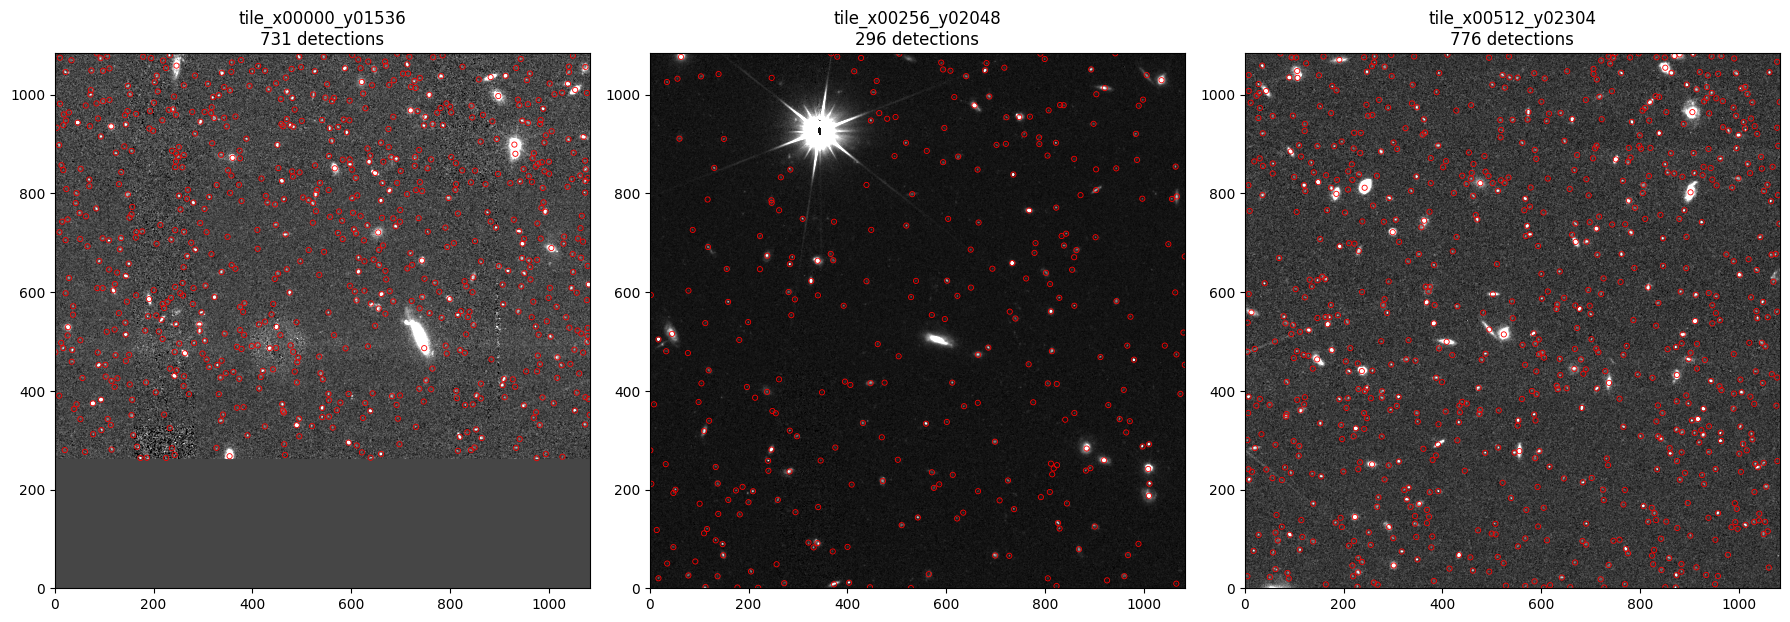

In [3]:
def zscale(img, lo=1.0, hi=99.5):
    f = img[np.isfinite(img)]
    return np.percentile(f, [lo, hi])

SHOW = ['tile_x00000_y01536', 'tile_x00256_y02048', 'tile_x00512_y02304']
show = [s for s in SHOW if s in labels] or list(labels.keys())[:3]

fig, axes = plt.subplots(1, len(show), figsize=(6 * len(show), 6))
axes = np.atleast_1d(axes)
for ax, stem in zip(axes, show):
    ed = np.load(EUCLID_DIR / f'{stem}_euclid.npz', allow_pickle=True)
    vis = np.nan_to_num(np.asarray(ed['img_VIS'], dtype=np.float32))
    H, W = vis.shape
    vlo, vhi = zscale(vis)
    ax.imshow(vis, origin='lower', cmap='gray', vmin=vlo, vmax=vhi)
    xy, _ = labels[stem]
    ax.scatter(xy[:, 0] * W, xy[:, 1] * H, s=14, facecolors='none',
               edgecolors='red', linewidths=0.6)
    ax.set_title(f'{stem}\n{xy.shape[0]} detections')
    ax.set_xlim(0, W); ax.set_ylim(0, H)
plt.tight_layout(); plt.show()

### 1b. Detection density vs ECDFS
A uniform shift in counts/tile is expected for a deeper/denser field; a long tail driven by a few tiles flags crowding artifacts.

ECDFS det/tile: mean 413.1 median 419


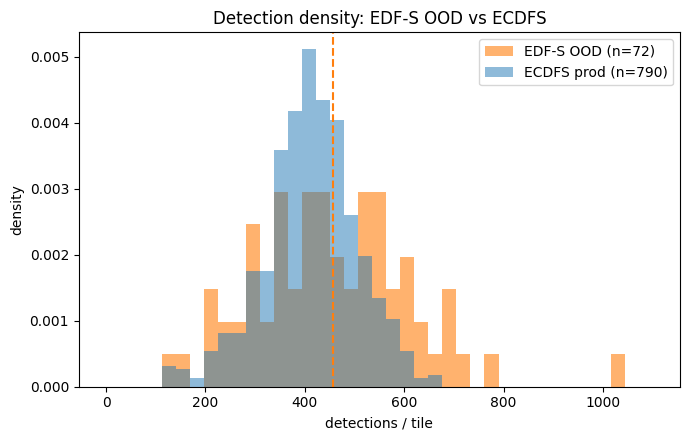

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, max(1100, ood_n.max()), 40)
ax.hist(ood_n, bins=bins, density=True, alpha=0.6, color='C1',
        label=f'EDF-S OOD (n={len(ood_n)})')
if ECDFS_CACHE.exists():
    ec = torch.load(ECDFS_CACHE, map_location='cpu', weights_only=False)
    ec_n = np.array([v[0].shape[0] for v in ec['labels'].values()])
    ax.hist(ec_n, bins=bins, density=True, alpha=0.5, color='C0',
            label=f'ECDFS prod (n={len(ec_n)})')
    print('ECDFS det/tile: mean %.1f median %d' % (ec_n.mean(), np.median(ec_n)))
ax.axvline(ood_n.mean(), color='C1', ls='--')
ax.set_xlabel('detections / tile'); ax.set_ylabel('density')
ax.set_title('Detection density: EDF-S OOD vs ECDFS'); ax.legend()
plt.tight_layout(); plt.show()

## 1d. Experiment — does local background subtraction recover detections near a bright star?

On both ECDFS (real `var`) and EDF-S, detection count anticorrelates with the fraction of the tile under bright extended flux (a star's halo + diffraction spikes). The hypothesis is that the detector does **no local background subtraction**, so faint sources sitting on the elevated pedestal lose contrast. Here we take the bright-star tile `tile_x00256_y02048` (296 dets), estimate a spatially-varying background per band with `sep`, subtract it, and re-run the *exact same* CenterNet. Compare detection count and overlay.

_This loads the foundation + detector, so it needs the GPU/CPU the export used. Run once._

In [5]:
import sys
MODELS = ROOT / 'models'
for _p in (str(MODELS), str(MODELS / 'detection')):
    if _p not in sys.path:
        sys.path.insert(0, _p)
from load_foundation import load_foundation
from jaisp_foundation_v10 import EUCLID_BANDS, RUBIN_BANDS
from detection.centernet_detector import CenterNetDetector
from detection.detector import JAISPEncoderWrapper
from detection.stem_centernet_detector import StemCenterNetDetector

ENC = ROOT / 'models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt'
CN  = ROOT / 'checkpoints/centernet_v10_uncertain_synth_r2/centernet_best.pt'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

foundation = load_foundation(str(ENC), device=torch.device('cpu'), freeze=True)
_ck = torch.load(str(CN), map_location='cpu', weights_only=True)
_mt = _ck.get('model_type', 'centernet')
if _mt == 'stem_centernet':
    detector = StemCenterNetDetector.load(str(CN), foundation=foundation, device=device).eval()
else:
    _enc = JAISPEncoderWrapper(foundation, freeze=True).to(device).eval()
    detector = CenterNetDetector.load(str(CN), encoder=_enc, device=device).eval()
print('loaded detector', _mt, 'on', device)

JAISPFoundationV10: 9.2M trainable parameters
  stem_ch=64, hidden_ch=256, fused_scale=0.40"/px
  stream_depths={'rubin': 1, 'euclid': 2}
  rubin_concat=True  (symmetric concat fusion)
  loss_type=charbonnier  charbonnier_eps=0.001  core_l2_weight=0.2  core_info_thr=0.5
  rubin decoder channels: [128]
  euclid decoder channels: [256, 128]
Loaded v10 foundation (fused_scale=0.4, rubin_concat=True, loss=charbonnier, core_l2=0.2) from /home/shemmati/Work/Projects/JAISP/models/checkpoints/jaisp_v10_warmstart/checkpoint_best.pt
loaded detector centernet on cuda


In [6]:
import sep
RUBIN_DIR = ROOT / 'data/edf_s_ood/rubin_tiles_edfs'

def _rms_from_img(img):
    med = float(np.median(img)); sig = max(float(1.4826 * np.median(np.abs(img - med))), 1e-10)
    return np.full_like(img, sig, dtype=np.float32)

def _bg_subtract(img, box_frac=16):
    a = np.ascontiguousarray(img, dtype=np.float32)
    bw = max(16, a.shape[0] // box_frac); bh = max(16, a.shape[1] // box_frac)
    bkg = sep.Background(a, bw=bw, bh=bh, fw=3, fh=3)
    return a - bkg.back(), np.asarray(bkg.back(), dtype=np.float32)

def build_dicts(stem, subtract_bg=False, box_frac=16):
    rd = np.load(RUBIN_DIR / f'{stem}.npz', allow_pickle=True)
    ed = np.load(EUCLID_DIR / f'{stem}_euclid.npz', allow_pickle=True)
    images, rms, bg_models = {}, {}, {}
    rimg = np.asarray(rd['img'], dtype=np.float32)
    for bi, band in enumerate(RUBIN_BANDS):
        img = np.nan_to_num(rimg[bi], nan=0.0)
        if subtract_bg:
            img, bg_models[band] = _bg_subtract(img, box_frac)
        rm = np.maximum(_rms_from_img(img), 1e-10)
        images[band] = torch.from_numpy(img[None, None].copy()).to(device)
        rms[band] = torch.from_numpy(rm[None, None].copy()).to(device)
    vis_hw = None
    for band in EUCLID_BANDS:
        k = band.split('_', 1)[1]
        img = np.nan_to_num(np.asarray(ed[f'img_{k}'], dtype=np.float32), nan=0.0)
        if subtract_bg:
            img, bg_models[band] = _bg_subtract(img, box_frac)
        rm = np.maximum(_rms_from_img(img), 1e-10)
        images[band] = torch.from_numpy(img[None, None].copy()).to(device)
        rms[band] = torch.from_numpy(rm[None, None].copy()).to(device)
        if k == 'VIS':
            vis_hw = img.shape
    return images, rms, vis_hw, bg_models

def run_detect(stem, subtract_bg=False, box_frac=16, conf=0.3):
    images, rms, vis_hw, bg = build_dicts(stem, subtract_bg, box_frac)
    with torch.no_grad():
        res = detector.predict(images, rms, conf_threshold=conf, tile_hw=vis_hw,
                               nms_kernel=7, artifact_mask=None)
    return res['centroids'].detach().cpu().numpy(), vis_hw, bg

In [7]:
STEM = 'tile_x00256_y02048'
xy0, vis_hw, _   = run_detect(STEM, subtract_bg=False)
xy1, _, bg       = run_detect(STEM, subtract_bg=True, box_frac=16)
print(f'baseline (no bg sub):   {len(xy0):4d} detections   (export cache had 296)')
print(f'sep bg-subtracted:      {len(xy1):4d} detections')
print(f'delta:                  {len(xy1) - len(xy0):+d}')

baseline (no bg sub):    306 detections   (export cache had 296)
sep bg-subtracted:       323 detections
delta:                  +17


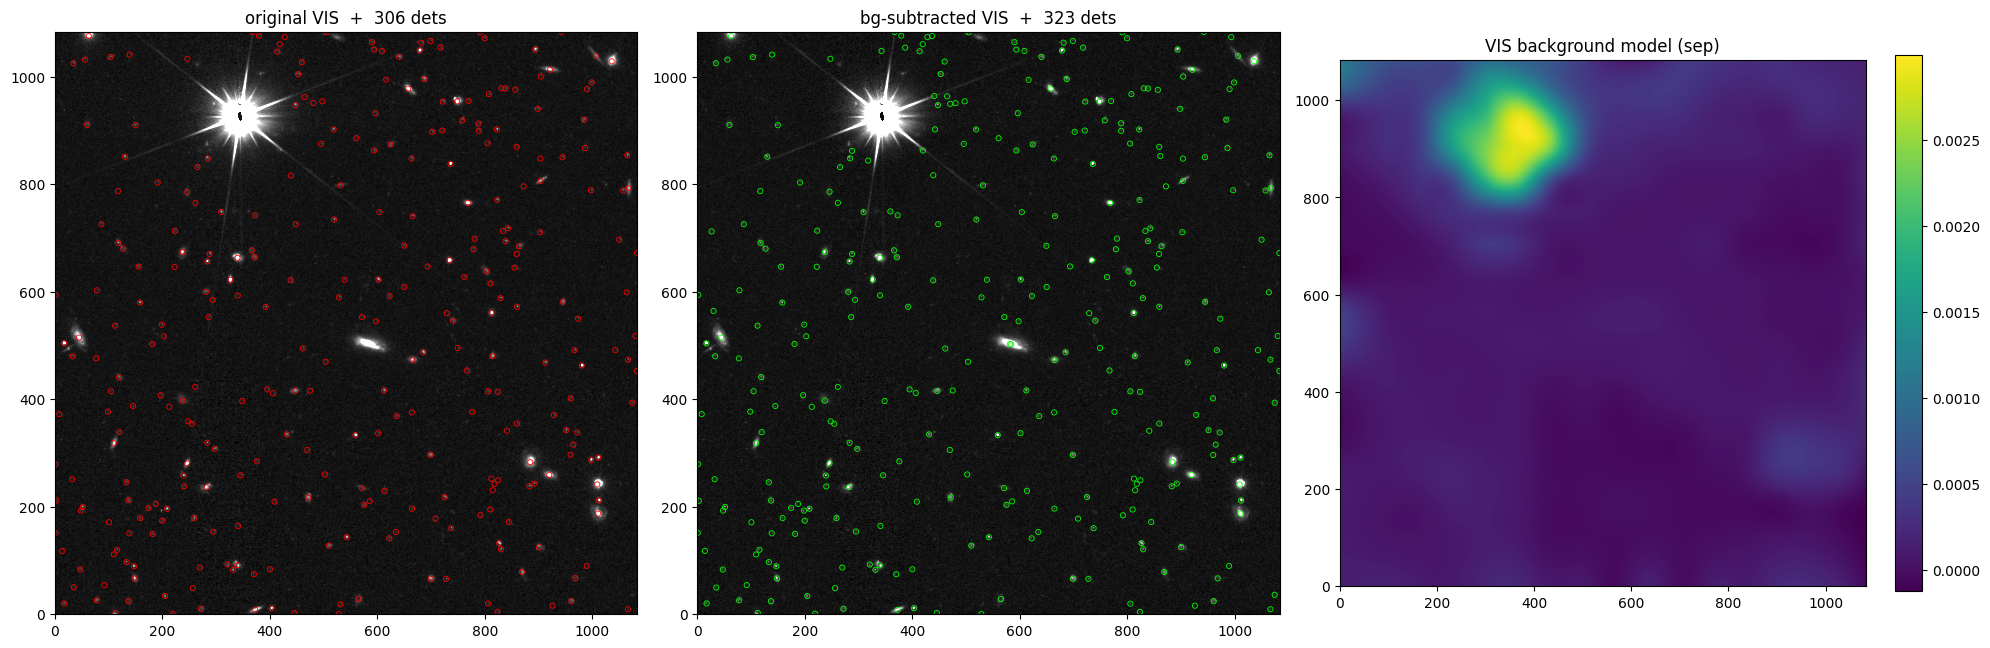

In [8]:
ed = np.load(EUCLID_DIR / f'{STEM}_euclid.npz', allow_pickle=True)
vis = np.nan_to_num(np.asarray(ed['img_VIS'], dtype=np.float32))
H, W = vis.shape
visbg = bg['euclid_VIS']
vissub = vis - visbg
vlo, vhi = zscale(vis)

fig, axs = plt.subplots(1, 3, figsize=(20, 6.8))
axs[0].imshow(vis, origin='lower', cmap='gray', vmin=vlo, vmax=vhi)
axs[0].scatter(xy0[:, 0] * W, xy0[:, 1] * H, s=14, facecolors='none', edgecolors='red', linewidths=0.6)
axs[0].set_title(f'original VIS  +  {len(xy0)} dets')
axs[1].imshow(vissub, origin='lower', cmap='gray', vmin=vlo, vmax=vhi)
axs[1].scatter(xy1[:, 0] * W, xy1[:, 1] * H, s=14, facecolors='none', edgecolors='lime', linewidths=0.6)
axs[1].set_title(f'bg-subtracted VIS  +  {len(xy1)} dets')
im = axs[2].imshow(visbg, origin='lower', cmap='viridis')
axs[2].set_title('VIS background model (sep)')
fig.colorbar(im, ax=axs[2], fraction=0.046)
for a in axs[:2]:
    a.set_xlim(0, W); a.set_ylim(0, H)
plt.tight_layout(); plt.show()

## Step 2 — Astrometry on EDF-S (joint canonical anchors)

The current production position instrument: CenterNet seeds → classical VIS refine → **joint multi-band canonical** position → per-band classical centroid → offset relative to the joint canonical. No neural head (the latent-head faint-end improvement was falsified); the foundation's OOD role here is the detection seeds. The per-band offset dispersion (band centroid vs the joint canonical) is the astrometric residual we compare to ECDFS.

**2026-06-24 (real var):** the EDF-S Euclid tiles now carry `var_*` maps, so `build_band_stack` and the exporter use real variance directly (the `_rms_from_var_or_image` MAD fallback only kicks in for NaN/no-coverage pixels). Switching from MAD-fallback to real var is a **re-weighting** of the joint-canonical fit: it pulls Rubin optical g/r/i/z *down* ~3–8 mas and lifts NISP ~4–9 mas. Net vs ECDFS (also real var), EDF-S is a uniform ~5–15% worse at matched SNR — the prior "NISP perfect / Rubin badly broken" split was largely the var fallback.

Export command (CPU multiprocessing; run once from repo root):

```bash
python models/astrometry2/export_joint_anchors.py \
    --rubin-dir       data/edf_s_ood/rubin_tiles_edfs \
    --euclid-dir      data/edf_s_ood/euclid_tiles_edfs \
    --detector-labels data/detection_labels/centernet_v10_edfs_thresh03.pt \
    --out             models/checkpoints/anchors_joint_canonical_edfs_var.npz \
    --workers 12
```

In [ ]:
# Compare EDF-S (OOD) joint-canonical anchors vs ECDFS reference
# 2026-06-24: real-var re-run. EDF-S Euclid tiles now carry var_* maps (redownloaded from ESA),
# so this uses the real-variance anchors. MAD-fallback version kept at ..._edfs_MADvar_backup.npz.
EDFS_ANCH  = ROOT / 'models/checkpoints/anchors_joint_canonical_edfs_var.npz'
ECDFS_ANCH = ROOT / 'models/checkpoints/anchors_joint_canonical_790.npz'
BANDS = ['u', 'g', 'r', 'i', 'z', 'y', 'nisp_Y', 'nisp_J', 'nisp_H']
SNR_BINS = [(5, 7), (7, 10), (10, 15), (15, 30), (30, np.inf)]

def band_stats(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    per_band, all_off, all_snr = {}, [], []
    for b in BANDS:
        if f'{b}_raw' not in d:
            continue
        off = d[f'{b}_raw']; snr = d[f'{b}_snr']
        r = np.hypot(off[:, 0], off[:, 1]) * 1000.0  # mas
        per_band[b] = (np.median(r), len(r))
        all_off.append(r); all_snr.append(snr)
    all_off = np.concatenate(all_off); all_snr = np.concatenate(all_snr)
    by_snr = {}
    for lo, hi in SNR_BINS:
        m = (all_snr >= lo) & (all_snr < hi)
        by_snr[f'{lo}-{hi if np.isfinite(hi) else "inf"}'] = (np.median(all_off[m]) if m.any() else np.nan, int(m.sum()))
    return per_band, by_snr, (np.median(all_off), len(all_off))

ood_pb, ood_snr, ood_pool = band_stats(EDFS_ANCH)
ec_pb,  ec_snr,  ec_pool  = band_stats(ECDFS_ANCH)

print('per-band median offset (mas)   band-vs-joint-canonical')
print('%-9s %12s %12s' % ('band', 'EDF-S OOD', 'ECDFS'))
for b in BANDS:
    o = ood_pb.get(b); e = ec_pb.get(b)
    print('%-9s %7.1f (N%5d) %7.1f' % (b, o[0], o[1], e[0]) if o else '%-9s   (missing)' % b)
print('\npooled median: EDF-S %.1f mas (N=%d)   ECDFS %.1f mas (N=%d)' %
      (ood_pool[0], ood_pool[1], ec_pool[0], ec_pool[1]))
print('\nby SNR (pooled median mas):')
print('%-10s %14s %10s' % ('SNR', 'EDF-S OOD', 'ECDFS'))
for k in ood_snr:
    print('%-10s %7.1f (N%5d) %7.1f' % (k, ood_snr[k][0], ood_snr[k][1], ec_snr[k][0]))

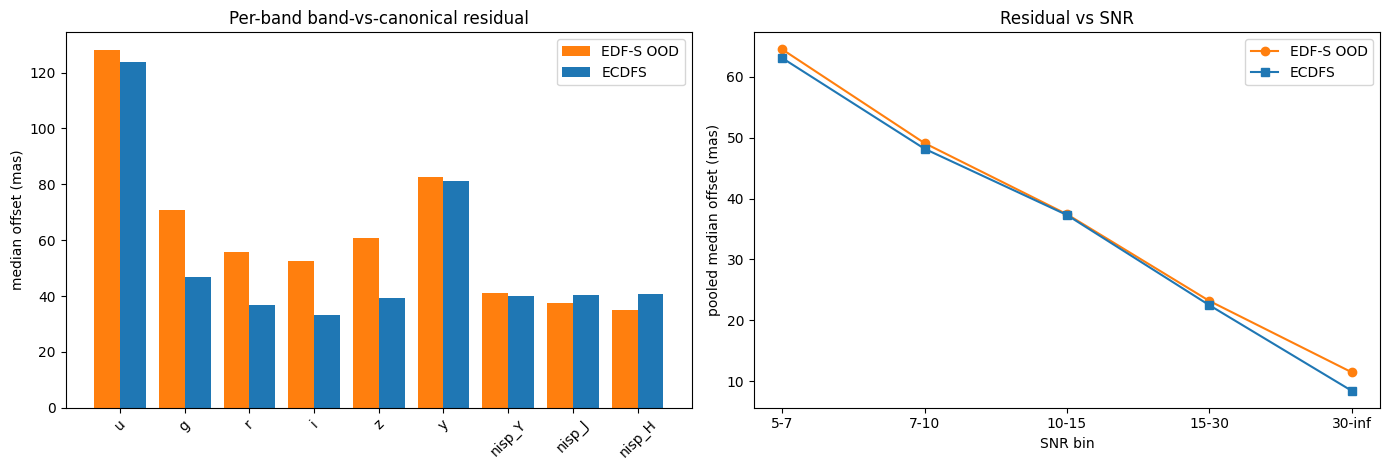

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(BANDS))
axs[0].bar(x - 0.2, [ood_pb[b][0] for b in BANDS], 0.4, label='EDF-S OOD', color='C1')
axs[0].bar(x + 0.2, [ec_pb[b][0] for b in BANDS], 0.4, label='ECDFS', color='C0')
axs[0].set_xticks(x); axs[0].set_xticklabels(BANDS, rotation=45)
axs[0].set_ylabel('median offset (mas)'); axs[0].set_title('Per-band band-vs-canonical residual'); axs[0].legend()

keys = list(ood_snr.keys())
xs = np.arange(len(keys))
axs[1].plot(xs, [ood_snr[k][0] for k in keys], 'o-', label='EDF-S OOD', color='C1')
axs[1].plot(xs, [ec_snr[k][0] for k in keys], 's-', label='ECDFS', color='C0')
axs[1].set_xticks(xs); axs[1].set_xticklabels(keys)
axs[1].set_xlabel('SNR bin'); axs[1].set_ylabel('pooled median offset (mas)')
axs[1].set_title('Residual vs SNR'); axs[1].legend()
plt.tight_layout(); plt.show()